# BREAST CANCER CLASSIFICATION - EXPLORATORY DATA ANALYSIS

In this notebook we explore the **breast cancer dataset** to understand it's structure, distributions, relationships between features and patterns that may help classify tumors. 

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

# 2. Load Dataset

In [8]:
df = pd.read_csv("../dataset/breast-cancer.csv")

# remove the first column of data frame
del df[df.columns[0]]

print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()

rows: 569, columns: 31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Column Description

| Column | diagnosis | radius_mean | texture_mean | perimeter_mean | area_mean | smoothness_mean | compactness_mean | concavity_mean | concave points_mean | symmetry_mean | fractal_dimension_mean | radius_se | texture_se | perimeter_se | area_se | smoothness_se | compactness_se | concavity_se | concave points_se | symmetry_se | fractal_dimension_se | radius_worst | texture_worst | perimeter_worst | area_worst | smoothness_worst | compactness_worst | concavity_worst | concave points_worst | symmetry_worst | fractal_dimension_worst
|:--------|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| Desc     | Target: M - Malignant B - Benign | Radius of Lobes | Mean of Surface Texture | Outer Perimeter of Lobes | Mean Area of Lobes | Mean of Smoothness Levels | Mean of Compactness | Mean of Concavity | Mean of Cocave Points | Mean of Symmetry | Mean of Fractal Dimension | SE of Radius | SE of Texture | SE of Perimeter | SE of Area | SE of Smoothness | SE of compactness | SE of concavity | SE of concave points | SE of symmetry | SE of Fractal Dimension | Worst Radius | Worst Texture | Worst Permimeter | Worst Area | Worst Smoothness | Worse Compactness | Worst Concavity | Worst Concave Points | Worst Symmetry | Worst Fractal Dimension |

# 3. Dataset Overview

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [12]:
df.describe(include="O").T

/var/folders/zd/4sstc_8n4wbcrx7s414tx9400000gn/T/ipykernel_14030/778510885.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O").T


,count,unique,top,freq
diagnosis,569,2,B,357


In [13]:
df.diagnosis.unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

# 4. Missing values Analysis

In [14]:
# Count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %


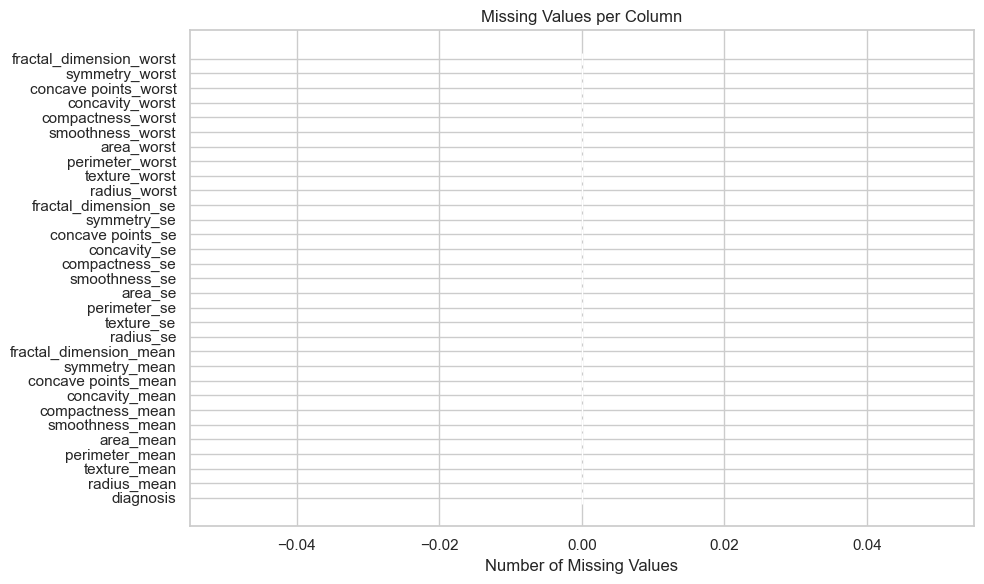

In [15]:

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if df[col].isnull().any() else "#2ecc71" for col in df.columns]
ax.barh(df.columns, df.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i, v in enumerate(df.isnull().sum()):
    if v > 0:
        ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Key observations :**  
* There is no missing values.

# 5. Target Variable Analysis

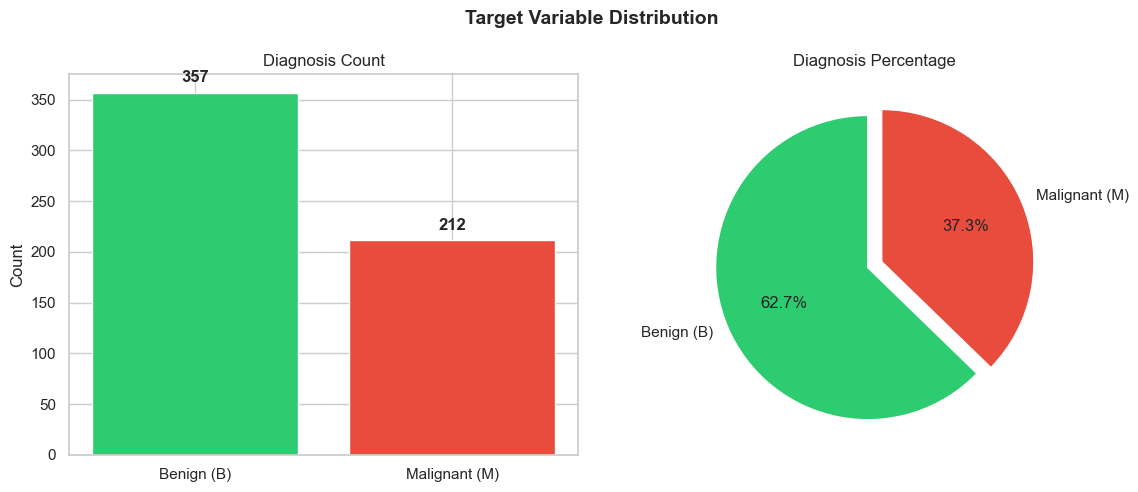

In [17]:
# Diagnosis distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
diagnosis_counts = df["diagnosis"].value_counts()
axes[0].bar(["Benign (B)", "Malignant (M)"], diagnosis_counts.values,
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Diagnosis Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(diagnosis_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(diagnosis_counts.values, labels=["Benign (B)", "Malignant (M)"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Diagnosis Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# print(f"\nBenign rate: {df['diagnosis'].mean():.2%}")
# print(f"Malignant rate: {1 - df['diagnosis'].mean():.2%}")

**Benign rate**: 62.7%  
**Malignant rate**: 37.3%  
The dataset is imbalanced — about 37% are mlaignant tumors and 63% are not.

# 6. Univariate Analysis — Numerical Features

In [24]:
len(numerical_cols.columns)

30

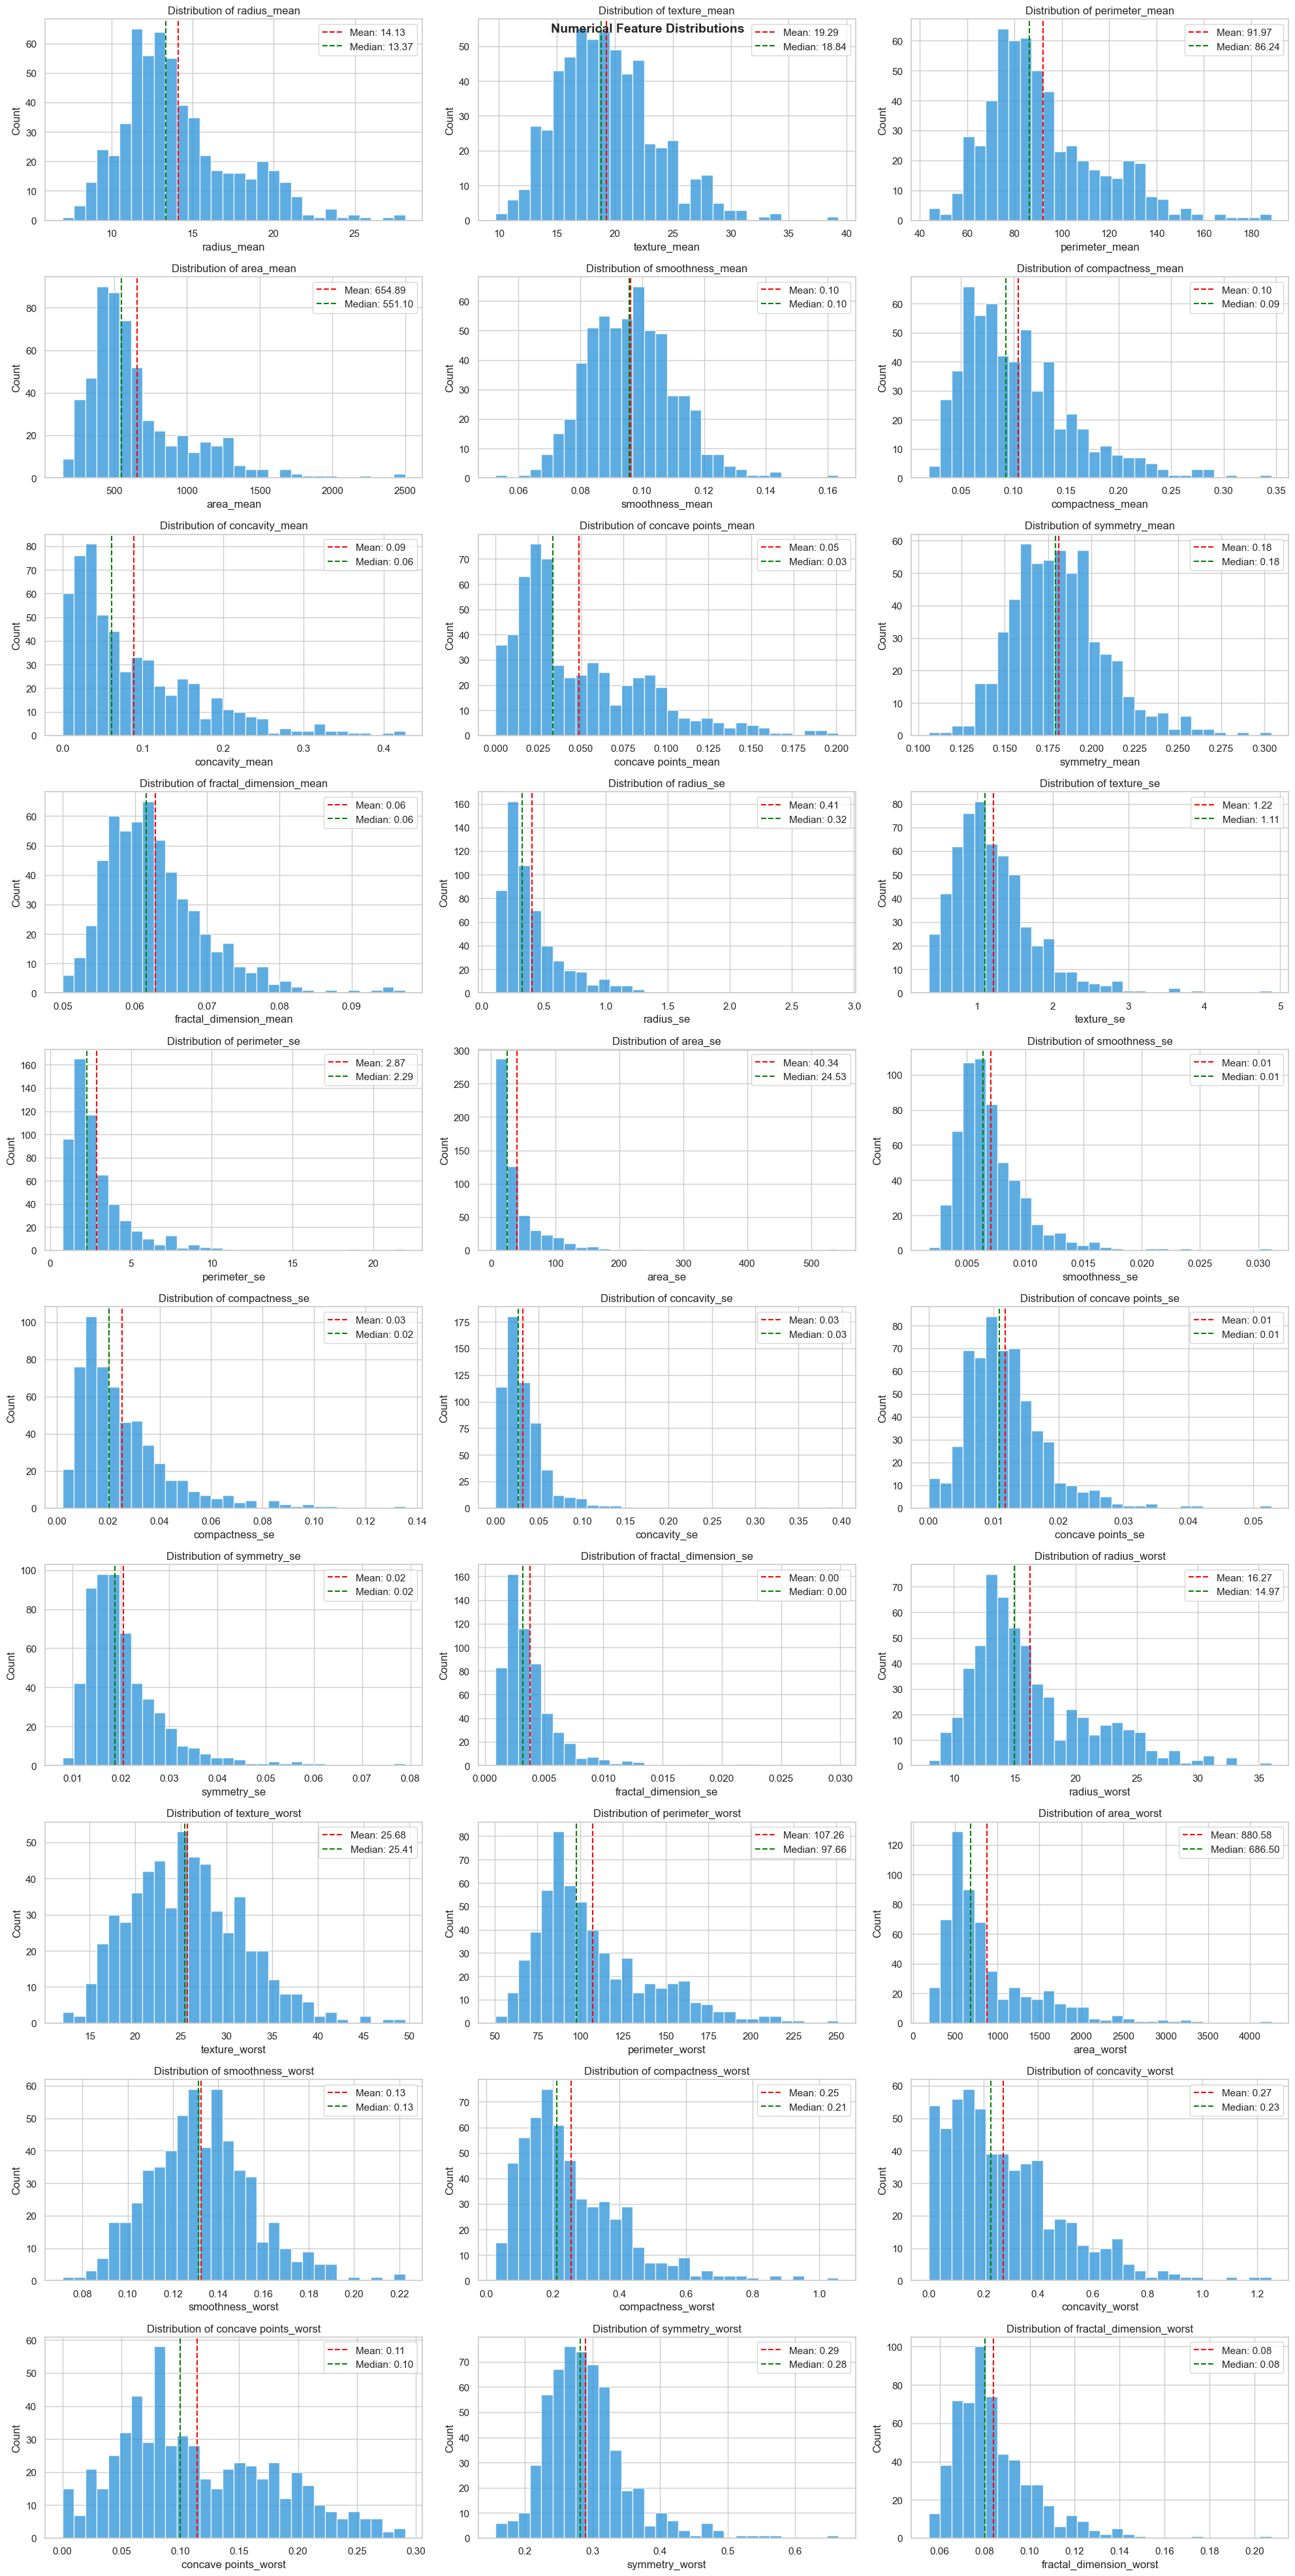

In [19]:
# Distribution of numerical features
numerical_cols = df.select_dtypes(exclude="object")

fig, axes = plt.subplots(10, 3, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<Axes: ylabel='area_mean'>

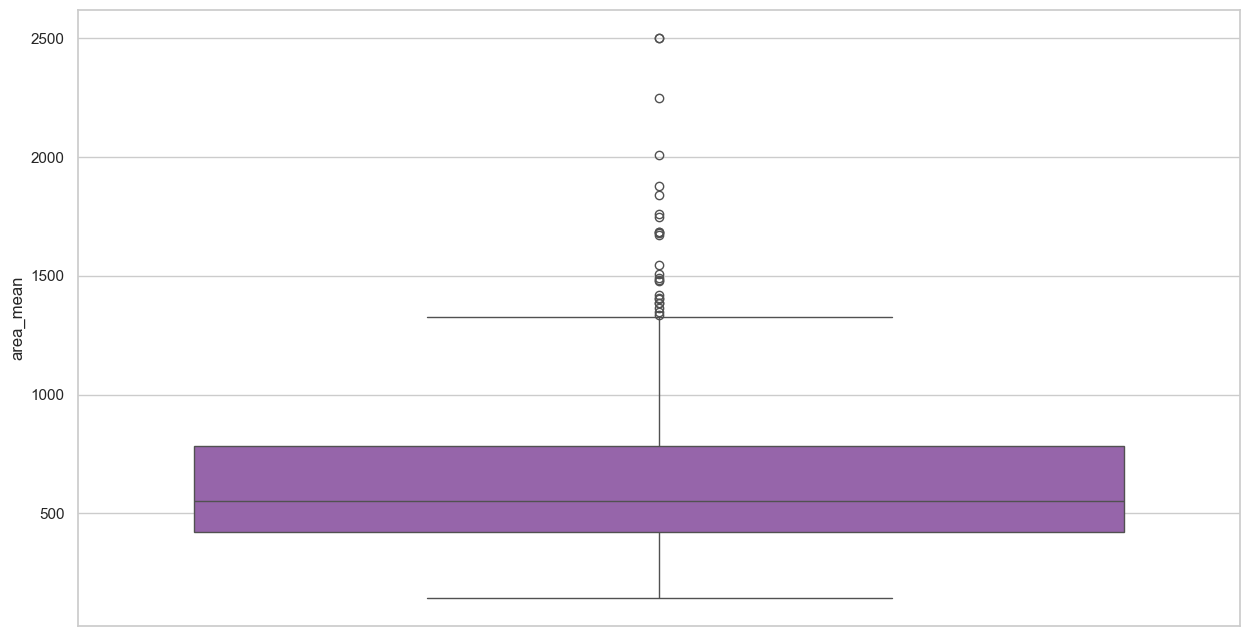

In [25]:
sns.boxplot(y=df['area_mean'], color="#9b59b6")

In [26]:
for i in range(0,30):
    print(f"{i//3}, {i%3}")

0, 0
0, 1
0, 2
1, 0
1, 1
1, 2
2, 0
2, 1
2, 2
3, 0
3, 1
3, 2
4, 0
4, 1
4, 2
5, 0
5, 1
5, 2
6, 0
6, 1
6, 2
7, 0
7, 1
7, 2
8, 0
8, 1
8, 2
9, 0
9, 1
9, 2


In [ ]:
# Box plots to check for outliers
fig, axes = plt.subplots(10, 3, figsize=(20, 40))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i // 3, i % 3], color="#9b59b6")
    axes[i // 3, i % 3].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations**:  
* **radius_mean; texture_mean; smoothness_mean; symmetry_mean; texture_se; fractal_dimension_mean; fractal_dimension_worst; concave_points_se; texture_worst; smoothness_worst; symmetry worst; concave points worst** :  
Roughly normaly distribued with some high outliers mostly significant for *radius_mean*, *symetry_mean*, *texture_se*, *fractal_dimension_mean*, *concave_points_se*, *fractal_dimension_worst* and *symetry_worst*.   

* The remaining variables are right-skewed, specialy heavy for *area_mean*, *concave_points_mean*, *concavity_mean*, *radius_se*, *area_se*, *perimeter_se*, *area_se*, *convacity_se* and *area_worst* with significant outliers.

# 7. Bivariate Analysis — Diagnosis vs Features

In [28]:
diagnosis_by = df.groupby(["diagnosis"]).mean()
diagnosis_by


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


In [ ]:
# Diagnosis rate by features
fig, axes = plt.subplots(10, 3, figsize=(20, 40))

diagnosis_by = df.groupby(["diagnosis"]).mean()
for i, col in enumerate(numerical_cols):
    axes[i // 3, i % 3].bar(diagnosis_by.index, diagnosis_by[col], color=["#95d0ad", "#a45c54"])
    axes[i // 3, i % 3].set_title(f"Average {col} by Diagnosis")
    axes[i // 3, i % 3].set_ylabel(f"Average {col}")
    for j, v in enumerate(diagnosis_by[col]):
        axes[i // 3, i % 3].text(j, v + 0.02 * v, f"{v:.2f}", ha="center", fontweight="bold")

plt.suptitle("Average Feature Values by Diagnosis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
df[df["diagnosis"] == 'B']

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
19,B,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
20,B,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
21,B,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
37,B,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
46,B,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,B,14.590,22.68,96.39,657.1,0.08473,0.13300,0.10290,0.037360,0.1454,...,15.480,27.27,105.90,733.5,0.10260,0.31710,0.36620,0.11050,0.2258,0.08004
559,B,11.510,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.041050,0.1388,...,12.480,37.16,82.28,474.2,0.12980,0.25170,0.36300,0.09653,0.2112,0.08732
560,B,14.050,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.043040,0.1537,...,15.300,33.17,100.20,706.7,0.12410,0.22640,0.13260,0.10480,0.2250,0.08321
561,B,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.000000,0.1060,...,11.920,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905


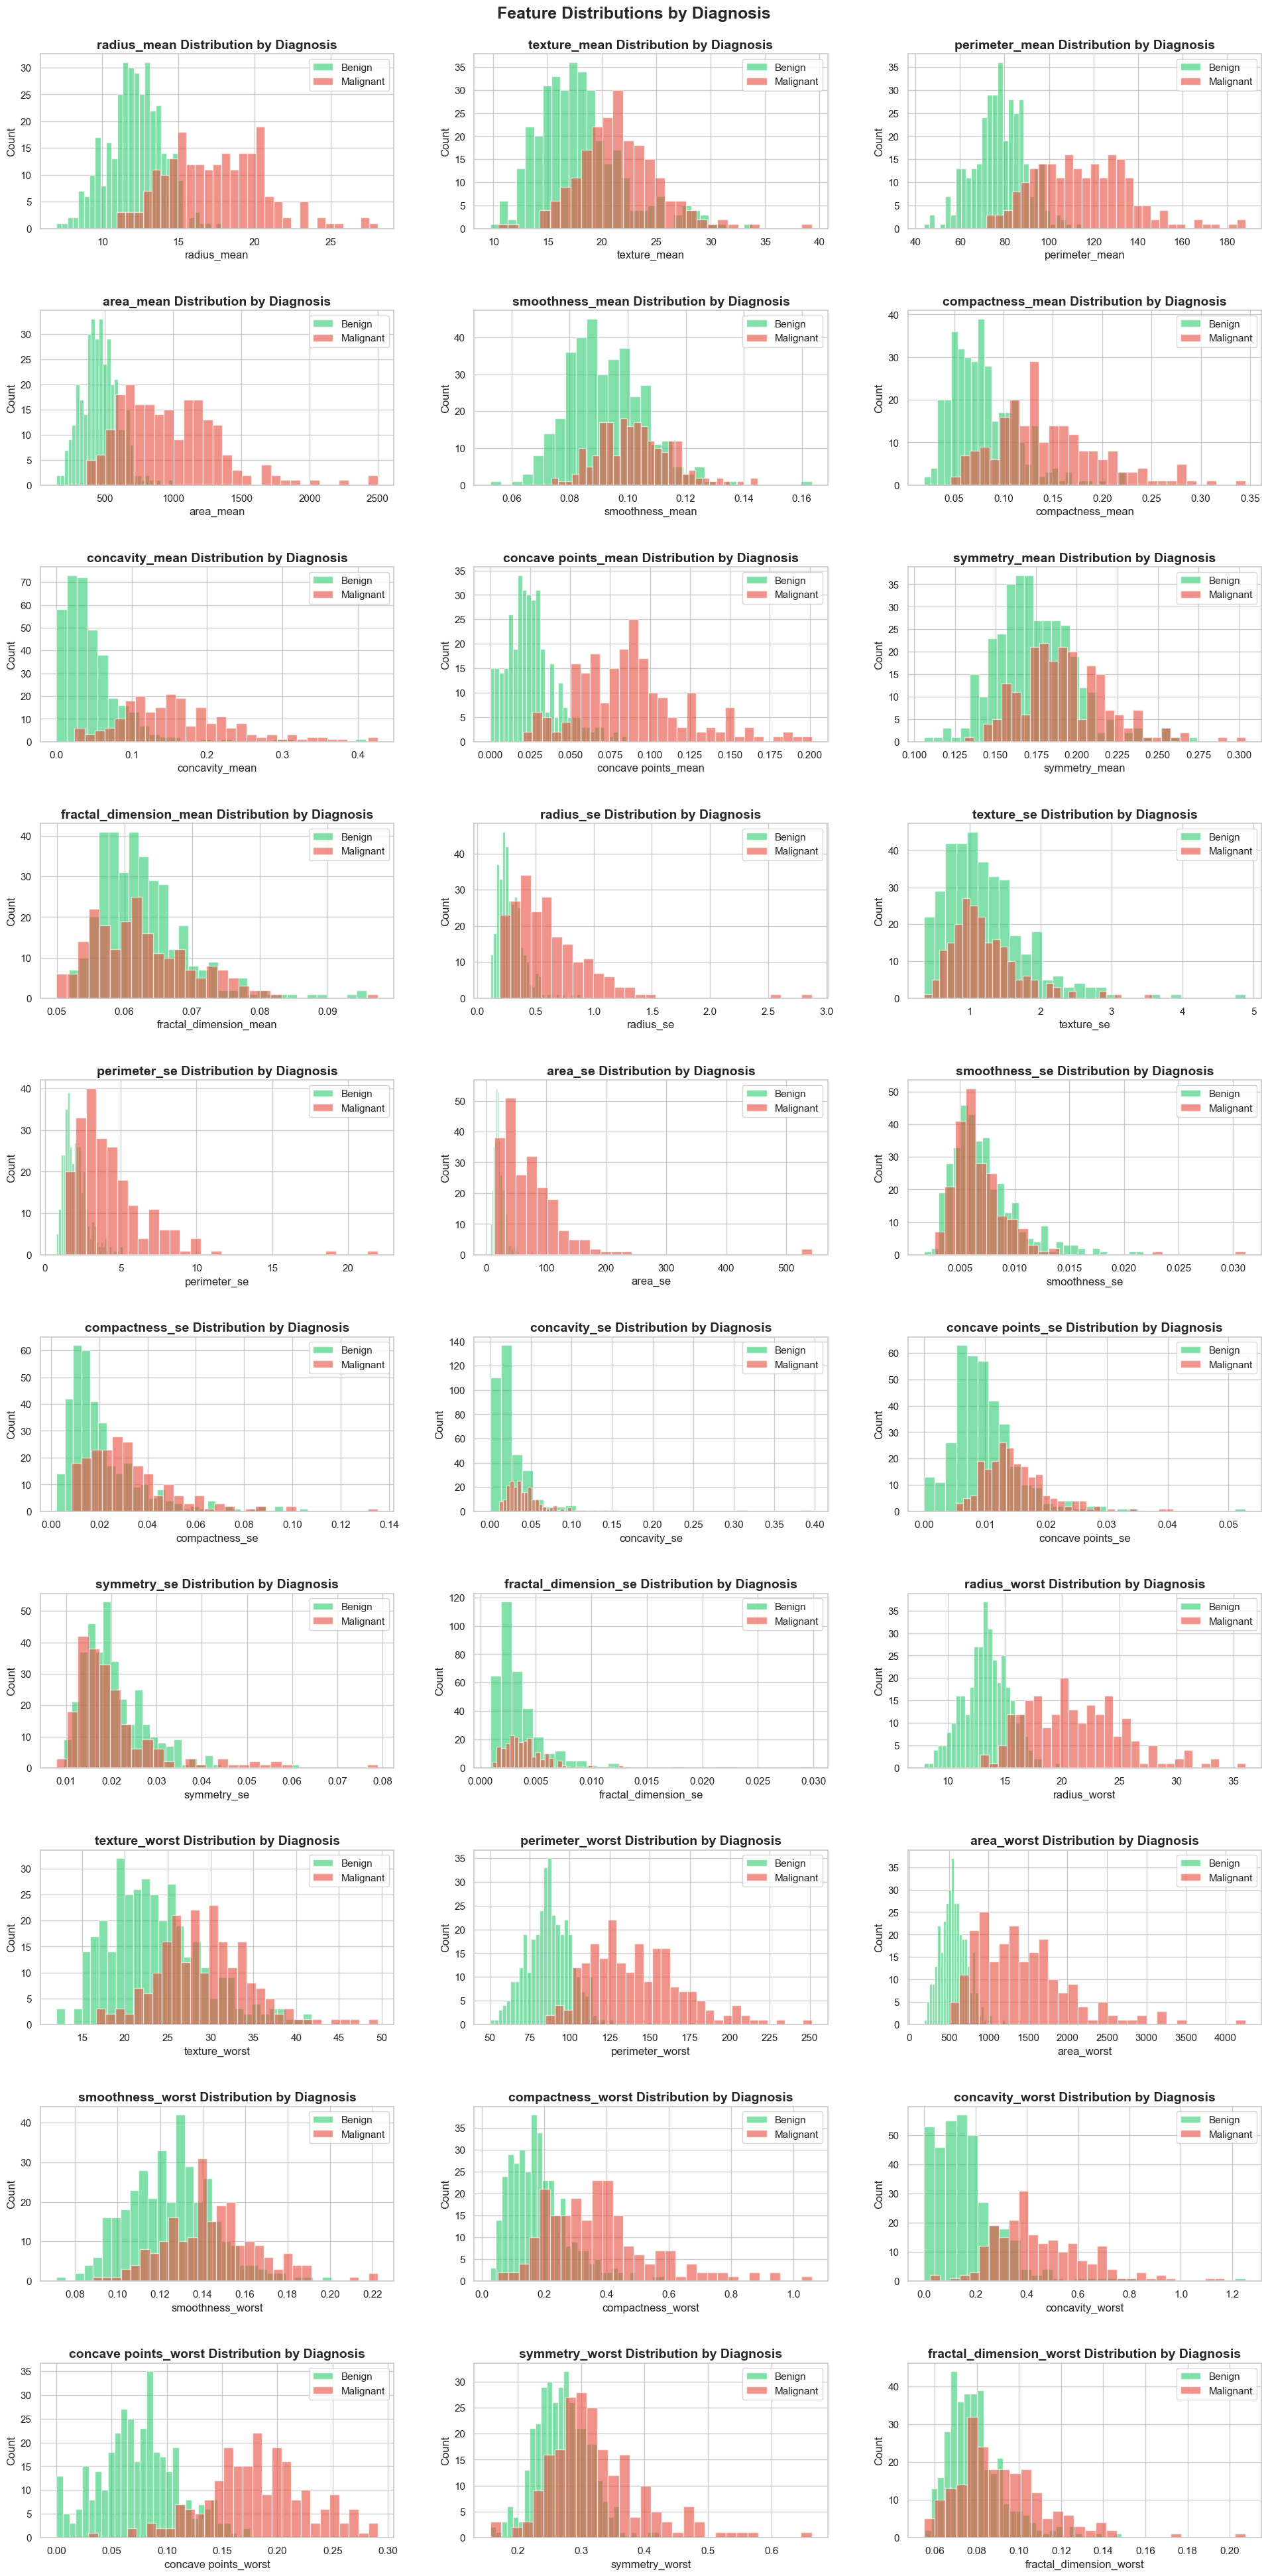

In [124]:
# Overlapping histograms
fig, axes = plt.subplots(10, 3, figsize=(20, 40))

for i, col in enumerate(numerical_cols):
    axes[i // 3, i % 3].hist(df[df["diagnosis"] == 'B'][col].dropna(), bins=30, alpha=0.6,
                color="#2ecc71", label="Benign", edgecolor="white")
    axes[i // 3, i % 3].hist(df[df["diagnosis"] == 'M'][col].dropna(), bins=30, alpha=0.6,
                color="#e74c3c", label="Malignant", edgecolor="white")
    axes[i // 3, i % 3].set_title(f"{col} Distribution by Diagnosis", fontsize=14, fontweight="bold")
    axes[i // 3, i % 3].set_xlabel(col)
    axes[i // 3, i % 3].set_ylabel("Count")
    axes[i // 3, i % 3].legend()

plt.suptitle("Feature Distributions by Diagnosis", fontsize=18, fontweight="bold")
plt.tight_layout(pad=3.2)
plt.show()

In [ ]:
# KDE plot
fig, axes = plt.subplots(10, 3, figsize=(20, 40))

for i, col in enumerate(numerical_cols):
    df[df["diagnosis"] == 'B'][col].dropna().plot.kde(ax=axes[i // 3, i % 3], color="#2ecc71",
                                                   label="Benign")
    df[df["diagnosis"] == 'M'][col].dropna().plot.kde(ax=axes[i // 3, i % 3], color="#e74c3c",
                                                   label="Malignant")
    axes[i // 3, i % 3].set_title(f"{col} by Diagnosis", fontweight="bold", pad=10)
    axes[i // 3, i % 3].set_xlabel(col)
    axes[i // 3, i % 3].legend()

plt.suptitle("KDE Plots of Features by Diagnosis", fontsize=18, fontweight="bold")
plt.tight_layout(pad=3.2)
plt.show()

# 8. Correlation Analysis

In [80]:
numerical_cols

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


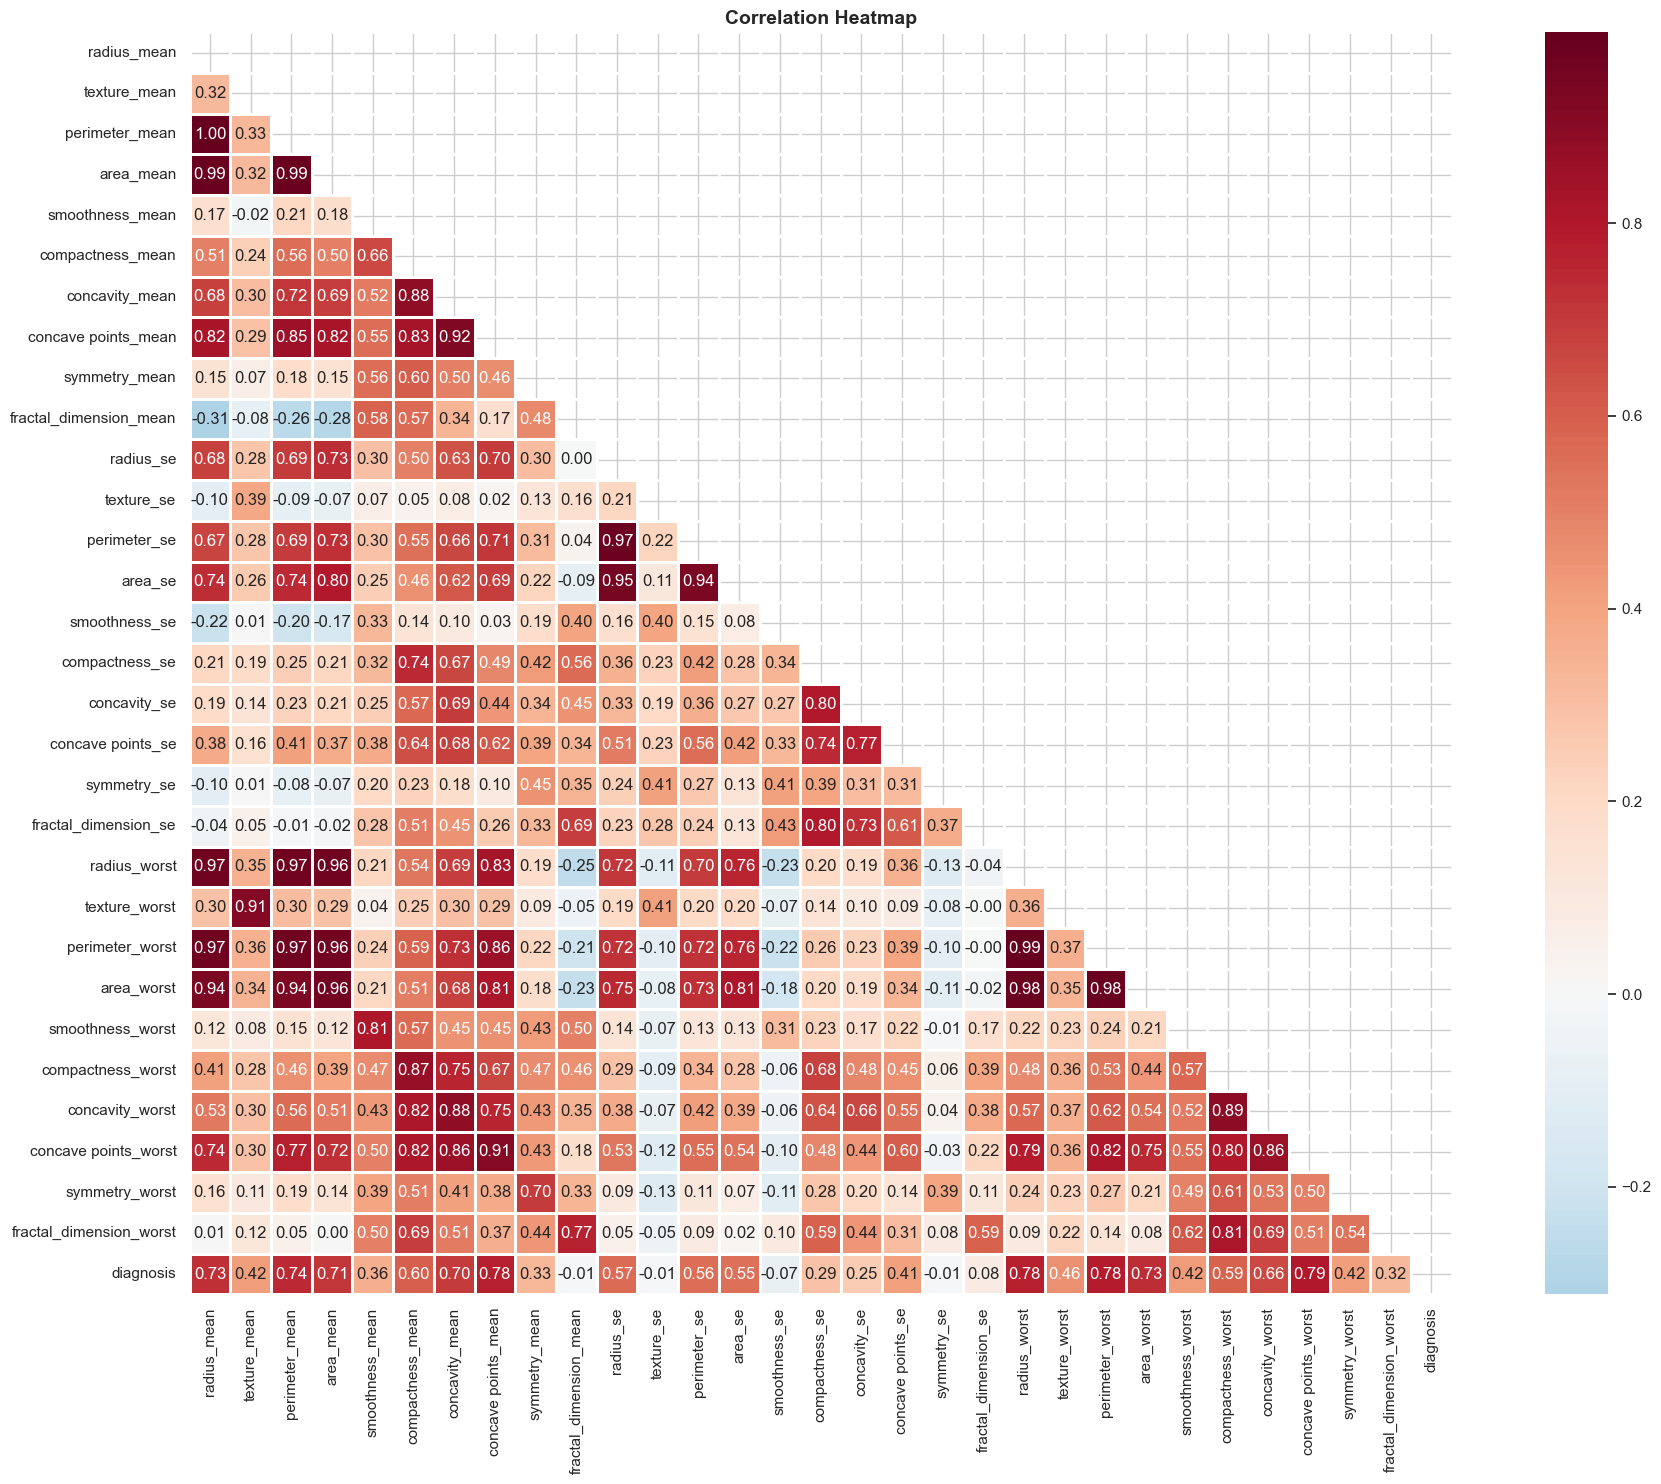

In [ ]:
# Correlation heatmap of numerical features
numeric_df = numerical_cols.copy()
numeric_df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(20, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

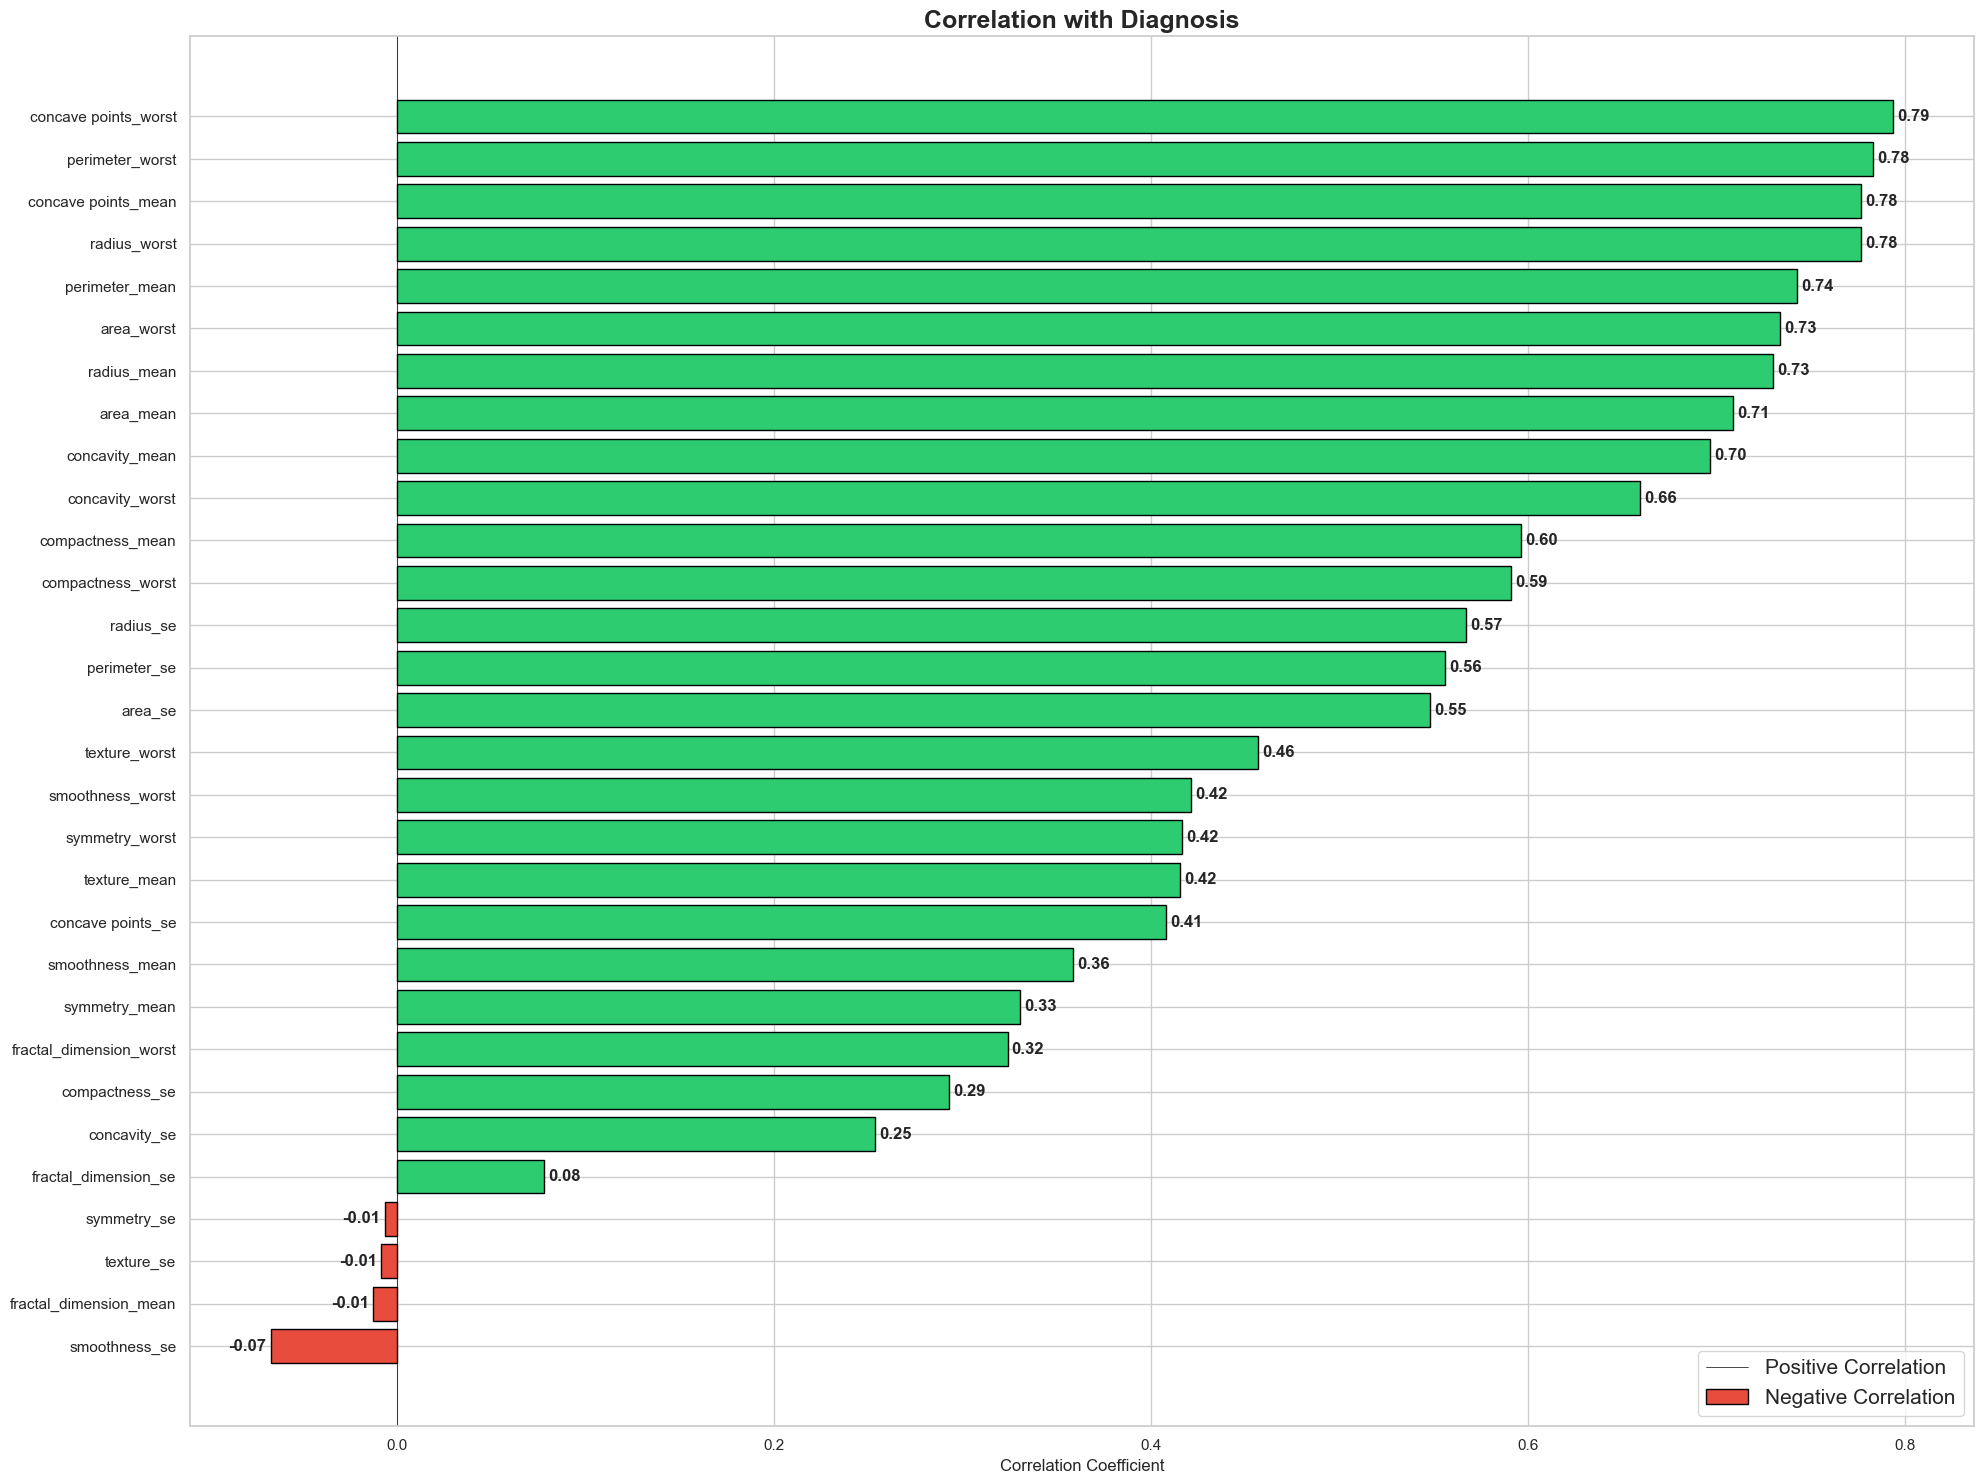

In [122]:
# Correlation with target
target_corr = corr["diagnosis"].drop("diagnosis").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(20, 15))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="black")
ax.set_title("Correlation with Diagnosis", fontsize=18, fontweight="bold")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontweight="bold")
ax.legend(["Positive Correlation", "Negative Correlation"], loc="lower right", fontsize=15)

plt.tight_layout()
plt.show()